In [67]:
import csv
import itertools
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

In [20]:

def construir_redes(archivo_csv):
    G_east_asian = nx.Graph()
    G_south_asian = nx.Graph()
    with open(archivo_csv, 'r', encoding='utf-8') as f:
        numero_recetas_east=0
        numero_recetas_south=0
        longitud_recetas_south=0
        longitud_recetas_east=0
        ingredientes_east = {}
        ingredientes_south = {}
        for linea in f:
            linea = linea.strip()
            
            if not linea or linea.startswith('#'):
                continue
                
            partes = linea.split(',')
            region = partes[0]
            ingredientes = partes[1:]
            if region == 'EastAsian':
                numero_recetas_east+=1
                longitud_recetas_east+=len(ingredientes)
                G = G_east_asian
                freq_dict = ingredientes_east
            elif region == 'SouthAsian':
                numero_recetas_south+=1
                longitud_recetas_south+=len(ingredientes)
                G = G_south_asian
                freq_dict = ingredientes_south
            else:
                continue

            for ingrediente in ingredientes:
                freq_dict[ingrediente] = freq_dict.get(ingrediente, 0) + 1
                
            for u, v in itertools.combinations(ingredientes, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)
            
    return G_east_asian, G_south_asian, numero_recetas_east, numero_recetas_south, longitud_recetas_south/numero_recetas_south, longitud_recetas_east/numero_recetas_east,ingredientes_east,ingredientes_south

archivo = '/home/antonio/Documents/Escuela/6to/Redes/Proyecto/Datos/srep00196-s3.csv'
g_e, g_s, nr_e, nr_s, lp_s, lp_e, e_ing,s_ing = construir_redes(archivo)

print(f"Red EastAsian: {g_e.number_of_nodes()} nodos (ingredientes), {g_e.number_of_edges()} aristas (conexiones), {nr_e} numero de recetas, {lp_e} longitud promedio de recetas.")
print(f"Red SouthAsian: {g_s.number_of_nodes()} nodos (ingredientes), {g_s.number_of_edges()} aristas (conexiones), {nr_s} numero de recetas, {lp_s} longitud promedio de recetas.")

Red EastAsian: 242 nodos (ingredientes), 6893 aristas (conexiones), 2512 numero de recetas, 8.956210191082803 longitud promedio de recetas.
Red SouthAsian: 205 nodos (ingredientes), 5328 aristas (conexiones), 621 numero de recetas, 10.286634460547504 longitud promedio de recetas.


Average Degree: 56.96694214876033


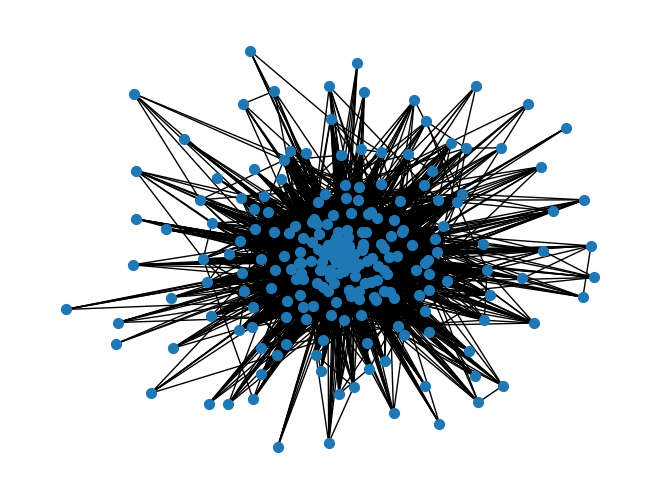

In [43]:
avg_degree = 2 * g_e.number_of_edges() / g_e.number_of_nodes()
print(f"Average Degree: {avg_degree}")
nx.draw(g_e, node_size=50)


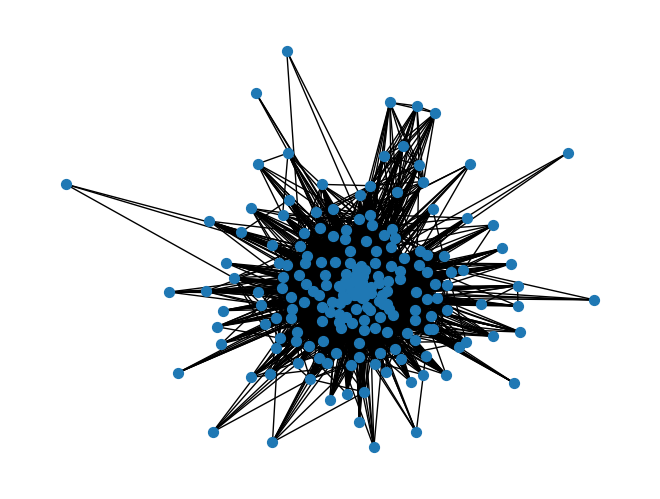

In [39]:
nx.draw(g_s, node_size=50)

In [29]:
top_nodos_east = sorted(e_ing.items(), key=lambda x: x[1], reverse=True)
print("Los 5 ingredientes en mas recetas Asia Oriental:")
for ingrediente, conexiones in top_nodos_est[:5]:
    print(f"{ingrediente}: {conexiones} conexiones")
top_nodos_south = sorted(s_ing.items(), key=lambda x: x[1], reverse=True)
print("Los 5 ingredientes en mas recetas Sur Asia:")
for ingrediente, conexiones in top_nodos_south[:5]:
    print(f"{ingrediente}: {conexiones} conexiones")

Los 5 ingredientes en mas recetas Asia Oriental:
soy_sauce: 1358 conexiones
garlic: 1302 conexiones
scallion: 1188 conexiones
cayenne: 1008 conexiones
sesame_oil: 937 conexiones
Los 5 ingredientes en mas recetas Sur Asia:
cumin: 375 conexiones
turmeric: 319 conexiones
onion: 316 conexiones
cayenne: 300 conexiones
garlic: 295 conexiones


In [3]:
ge_d = g_e.degree(weight='weight')
top_nodos_south = sorted(ge_d, key=lambda x: x[1], reverse=True)
print("Los 5 ingredientes con más conexiones en Asia Oriental:")
for ingrediente, conexiones in top_nodos_south[:5]:
    print(f"{ingrediente}: {conexiones} conexiones")
gs_d = g_s.degree(weight='weight')
top_nodos_south = sorted(gs_d, key=lambda x: x[1], reverse=True)
print("Los 5 ingredientes con más conexiones en Sur Asia:")
for ingrediente, conexiones in top_nodos_south[:5]:
    print(f"{ingrediente}: {conexiones} conexiones")

Los 5 ingredientes con más conexiones en Asia Oriental:
garlic: 12620 conexiones
soy_sauce: 12490 conexiones
scallion: 11162 conexiones
cayenne: 9470 conexiones
sesame_oil: 8793 conexiones
Los 5 ingredientes con más conexiones en Sur Asia:
cumin: 4215 conexiones
turmeric: 3747 conexiones
onion: 3655 conexiones
coriander: 3561 conexiones
garlic: 3442 conexiones


In [34]:
#Densidad de las redes
east_numero_nodos=g_e.number_of_nodes(); south_numero_nodos=g_s.number_of_nodes();
east_numero_aristas=g_e.number_of_edges(); south_numero_aristas=g_s.number_of_edges();
print(fr"Denisadad red este: {east_numero_aristas/((east_numero_nodos)*(east_numero_nodos-1))}")
print(fr"Denisadad red sur: {south_numero_aristas/((south_numero_nodos)*(south_numero_nodos-1))}")

Denisadad red este: 0.11818867665717911
Denisadad red sur: 0.12740315638450503


In [5]:
#Componentes Conexas
print(fr"Numero de componentes conexas east: {nx.number_connected_components(g_e)}")
print(fr"Numero de componentes conexas south: {nx.number_connected_components(g_s)}")

Numero de componentes conexas east: 1
Numero de componentes conexas south: 1


Grado Promedio East: 889.9504132231405
Grado Promedio South: 351.8048780487805


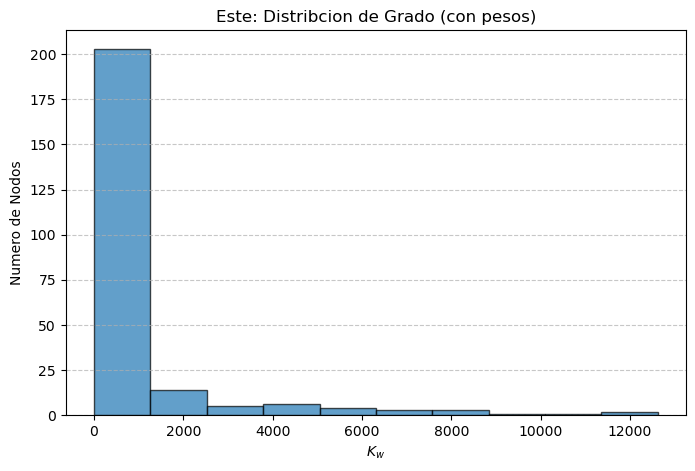

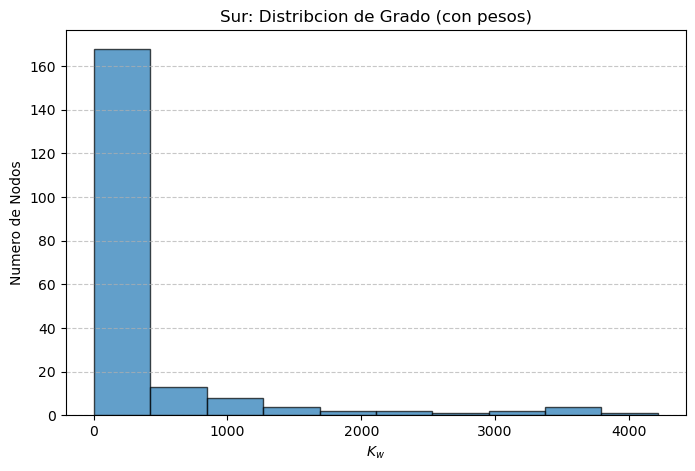

In [35]:
#Grado Primedio
e_wdegrees = dict(g_e.degree(weight='weight'))
s_wdegrees = dict(g_s.degree(weight='weight'))
print(fr"Grado Promedio East: {sum(e_wdegrees.values())/east_numero_nodos}")
print(fr"Grado Promedio South: {sum(s_wdegrees.values())/south_numero_nodos}")

#Distribucion de Grado
plt.figure(figsize=(8, 5))
plt.hist(e_wdegrees.values(), bins=10, edgecolor="black", alpha=0.7)
plt.title("Este: Distribcion de Grado (con pesos)")
plt.xlabel(fr"$K_w$")
plt.ylabel(fr"Numero de Nodos")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Este: Distribcion de Grado (con pesos)")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(s_wdegrees.values(), bins=10, edgecolor="black", alpha=0.7)
plt.title("Sur: Distribcion de Grado (con pesos)")
plt.xlabel(fr"$K_w$")
plt.ylabel(fr"Numero de Nodos")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Sur: Distribcion de Grado (con pesos)")
plt.show()

In [7]:
#Clustering
eavg_clustering = nx.average_clustering(g_e)
eavg_wclustering = nx.average_clustering(g_e, weight='weight')
savg_clustering = nx.average_clustering(g_s)
savg_wclustering = nx.average_clustering(g_s, weight='weight')
print(fr"Este")
print(fr"Coeficinete de clustering: {eavg_clustering}")
print(fr"Coeficinete de clustering (weighted): {eavg_wclustering}")
print(fr"Sur")
print(fr"Coeficinete de clustering: {savg_clustering}")
print(fr"Coeficinete de clustering (weighted): {savg_wclustering}")

Este
Coeficinete de clustering: 0.774686544334634
Coeficinete de clustering (weighted): 0.0063776537798469705
Sur
Coeficinete de clustering: 0.7814763242541625
Coeficinete de clustering (weighted): 0.011719658391234644


In [8]:
#Distancia promedio y diametro
e_diameter = nx.diameter(g_e)
e_distprom = nx.average_shortest_path_length(g_e)
s_diameter = nx.diameter(g_s)
s_distprom = nx.average_shortest_path_length(g_s)

print(fr"Este")
print(fr"Diametro: {e_diameter}")
print(fr"Distancia mas corta promedio: {e_distprom}")
print(fr"Sur")
print(fr"Diametro: {s_diameter}")
print(fr"Distancia mas corta promedio: {s_distprom}")

Este
Diametro: 3
Distancia mas corta promedio: 1.7866671238983574
Sur
Diametro: 3
Distancia mas corta promedio: 1.7773314203730273


In [9]:
#Intermediacion
e_bet = nx.betweenness_centrality(g_e)
e_top_10 = sorted(e_bet.items(), key=lambda item: item[1], reverse=True)[:10]
print("Este top 10 nodos intermedicion:")
for rank, (node, score) in enumerate(e_top_10, start=1):
    print(f"{rank}. Node {node}: {score:.4f}")
s_bet = nx.betweenness_centrality(g_s)
s_top_10 = sorted(s_bet.items(), key=lambda item: item[1], reverse=True)[:10]
print("Sur top 10 nodos intermedicion:")
for rank, (node, score) in enumerate(s_top_10, start=1):
    print(f"{rank}. Node {node}: {score:.4f}")

Este top 10 nodos intermedicion:
1. Node rice: 0.0591
2. Node vegetable_oil: 0.0553
3. Node soy_sauce: 0.0409
4. Node egg: 0.0356
5. Node ginger: 0.0341
6. Node garlic: 0.0325
7. Node scallion: 0.0256
8. Node vinegar: 0.0231
9. Node wheat: 0.0214
10. Node black_pepper: 0.0192
Sur top 10 nodos intermedicion:
1. Node cumin: 0.0442
2. Node coriander: 0.0403
3. Node garlic: 0.0360
4. Node ginger: 0.0350
5. Node onion: 0.0346
6. Node turmeric: 0.0281
7. Node cayenne: 0.0263
8. Node cream: 0.0243
9. Node pepper: 0.0239
10. Node butter: 0.0237


In [10]:
#Cercania
e_bet = nx.closeness_centrality(g_e)
e_top_10 = sorted(e_bet.items(), key=lambda item: item[1], reverse=True)[:10]
print("Este top 10 nodos cercania:")
for rank, (node, score) in enumerate(e_top_10, start=1):
    print(f"{rank}. Node {node}: {score:.4f}")
s_bet = nx.closeness_centrality(g_s)
s_top_10 = sorted(s_bet.items(), key=lambda item: item[1], reverse=True)[:10]
print("Sur top 10 nodos cercania:")
for rank, (node, score) in enumerate(s_top_10, start=1):
    print(f"{rank}. Node {node}: {score:.4f}")

Este top 10 nodos intermedicion:
1. Node rice: 0.8516
2. Node vegetable_oil: 0.8456
3. Node soy_sauce: 0.8339
4. Node garlic: 0.8169
5. Node ginger: 0.8060
6. Node egg: 0.8007
7. Node scallion: 0.7902
8. Node vinegar: 0.7850
9. Node sesame_oil: 0.7675
10. Node black_pepper: 0.7415
Sur top 10 nodos intermedicion:
1. Node cumin: 0.8793
2. Node coriander: 0.8718
3. Node onion: 0.8500
4. Node ginger: 0.8395
5. Node turmeric: 0.8395
6. Node garlic: 0.8361
7. Node pepper: 0.8095
8. Node fenugreek: 0.8063
9. Node cayenne: 0.7969
10. Node vegetable_oil: 0.7669


In [11]:
def shared_ingridients(G1,G2):
    ns1=G1.nodes();
    ns2=G2.nodes();
    ingredientes_compartidos=[];
    for n1 in ns1:
        for n2 in ns2:
            if n1 == n2:
                ingredientes_compartidos.append(n1)
            else:
                continue
    return ingredientes_compartidos

nshi = len(shared_ingridients(g_e,g_s))
print(fr"Proporcion de Red Compartida (Este): {nshi/east_numero_nodos}")
print(fr"Proporcion de Red Compartida (Sur): {nshi/south_numero_nodos}")

Proporcion de Red Compartida (Este): 0.7066115702479339
Proporcion de Red Compartida (Sur): 0.8341463414634146


In [60]:
#Modelos Aleatrios
def comparacion_erdos(G, nombre_red):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    k_avg = (2 * E) / N
    p = k_avg / (N - 1)
    densidad_real = nx.density(G)
    clust_r = nx.average_clustering(G)
    G_er = nx.erdos_renyi_graph(n=N, p=p)
    E_er = G_er.number_of_edges()
    k_avg_er = (2 * E_er) / N
    clust_er=nx.average_clustering(G_er)
    densidad_er = nx.density(G_er)
    print(f"--- Comparación Erdős-Rényi: {nombre_red} ---")
    print(f"Nodos (N): {N}")
    print(f"Probabilidad calculada (p): {p:.4f}")
    print(f"Enlaces (E): Real = {E} | Erdős-Rényi = {E_er}")
    print(f"Grado Promedio (<k>): Real = {k_avg:.2f} | Erdős-Rényi = {k_avg_er:.2f}")
    print(f"Densidad (\u03c1): Real = {densidad_real:.5f} | Erdős-Rényi = {densidad_er:.5f}")
    print(f"Clustering (\u03c1): Real = {clust_r:.5f} | Erdős-Rényi = {clust_er:.5f}")

    print("-" * 45 + "\n")
    return G_er

In [63]:
er_e=comparacion_erdos(g_e, "Este de Asia")
er_s=comparacion_erdos(g_s, "Este de Asia")

--- Comparación Erdős-Rényi: Este de Asia ---
Nodos (N): 242
Probabilidad calculada (p): 0.2364
Enlaces (E): Real = 6893 | Erdős-Rényi = 6901
Grado Promedio (<k>): Real = 56.97 | Erdős-Rényi = 57.03
Densidad (ρ): Real = 0.23638 | Erdős-Rényi = 0.23665
Clustering (ρ): Real = 0.77469 | Erdős-Rényi = 0.23787
---------------------------------------------

--- Comparación Erdős-Rényi: Este de Asia ---
Nodos (N): 205
Probabilidad calculada (p): 0.2548
Enlaces (E): Real = 5328 | Erdős-Rényi = 5277
Grado Promedio (<k>): Real = 51.98 | Erdős-Rényi = 51.48
Densidad (ρ): Real = 0.25481 | Erdős-Rényi = 0.25237
Clustering (ρ): Real = 0.78148 | Erdős-Rényi = 0.25425
---------------------------------------------



Plotting degree distributions...



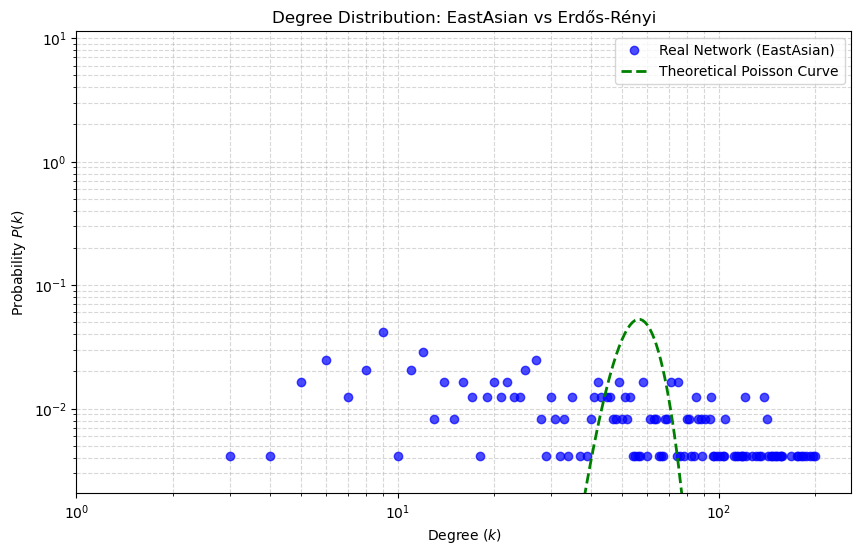

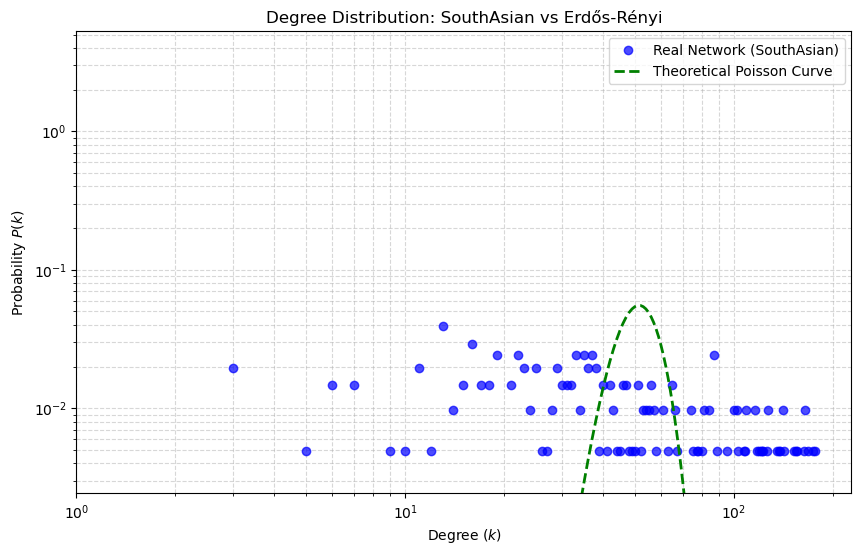

In [75]:
def plot_degree_distribution(G, G_er, network_name, name):
    degrees_real = [d for n, d in G.degree()]
    #degrees_er = [d for n, d in G_er.degree()]
    k_real, counts_real = np.unique(degrees_real, return_counts=True)
    pk_real = counts_real / sum(counts_real)
    
    #k_er, counts_er = np.unique(degrees_er, return_counts=True)
    #pk_er = counts_er / sum(counts_er)
    k_avg = np.mean(degrees_real)
    k_max = max(k_real)
    k_theoretical = np.arange(0, k_max + 1)
    pk_theoretical = poisson.pmf(k_theoretical, k_avg)
    plt.figure(figsize=(10, 6))
    plt.plot(k_real, pk_real, 'bo', label=f'Real Network ({network_name})', alpha=0.7)
    #plt.plot(k_er, pk_er, 'rs', label='Generated Erdős-Rényi', alpha=0.7)
    plt.plot(k_theoretical, pk_theoretical, 'g--', label='Theoretical Poisson Curve', linewidth=2)
    plt.title(f'Degree Distribution: {network_name} vs Erdős-Rényi')
    plt.xlabel('Degree ($k$)')
    plt.ylabel('Probability $P(k)$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(left=1)
    plt.ylim(bottom=min(pk_real) / 2)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.savefig(name)
    plt.show()

print("Plotting degree distributions...\n")
plot_degree_distribution(g_e, er_e, "EastAsian", "Comparacion East Erdos")
plot_degree_distribution(g_s, er_s, "SouthAsian", "Comparacion South Erdos")

Generando redes nulas Barabási-Albert y graficando...

--- Comparación Barabási-Albert: EastAsian ---
Nodos (N): 242
Parámetro calculado (m): Exacto = 28.483 | Redondeado = 28
Enlaces (E): Real = 6893 | Barabási-Albert = 5992
Grado Promedio (<k>): Real = 56.967 | Barabási-Albert = 49.521
Densidad (ρ): Real = 0.23638 | Barabási-Albert = 0.20548
--------------------------------------------------



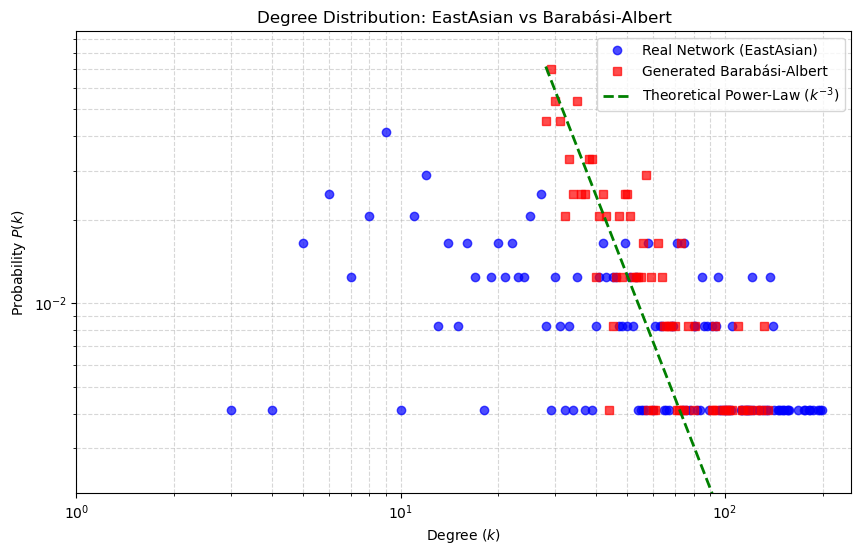

--- Comparación Barabási-Albert: SouthAsian ---
Nodos (N): 205
Parámetro calculado (m): Exacto = 25.990 | Redondeado = 26
Enlaces (E): Real = 5328 | Barabási-Albert = 4654
Grado Promedio (<k>): Real = 51.980 | Barabási-Albert = 45.405
Densidad (ρ): Real = 0.25481 | Barabási-Albert = 0.22257
--------------------------------------------------



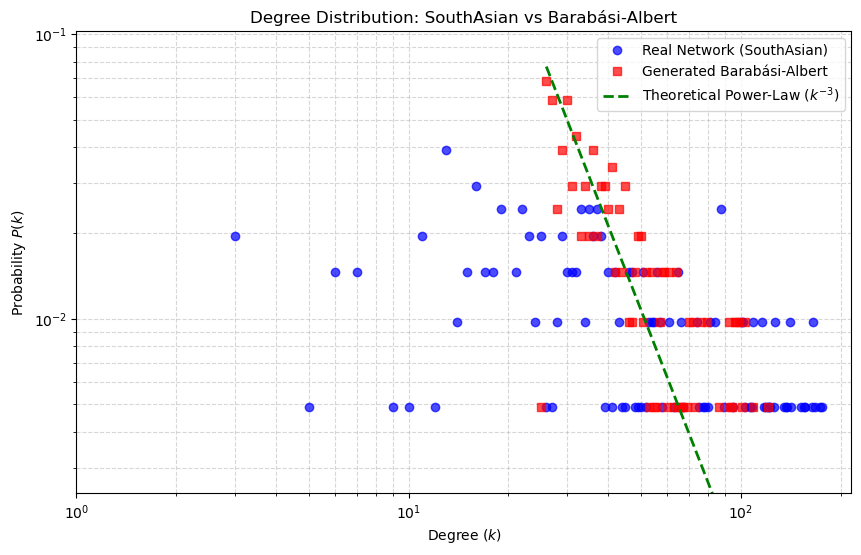

In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def comparacion_barabasi(G, nombre_red):

    N = G.number_of_nodes()
    E = G.number_of_edges()
    
    k_avg = (2 * E) / N
    densidad_real = nx.density(G)

    m_exacto = E / N
    m = int(round(m_exacto))
    
    G_ba = nx.barabasi_albert_graph(n=N, m=m)
    
    E_ba = G_ba.number_of_edges()
    k_avg_ba = (2 * E_ba) / N
    densidad_ba = nx.density(G_ba)
    
    print(f"--- Comparación Barabási-Albert: {nombre_red} ---")
    print(f"Nodos (N): {N}")
    print(f"Parámetro calculado (m): Exacto = {m_exacto:.3f} | Redondeado = {m}")
    print(f"Enlaces (E): Real = {E} | Barabási-Albert = {E_ba}")
    print(f"Grado Promedio (<k>): Real = {k_avg:.3f} | Barabási-Albert = {k_avg_ba:.3f}")
    print(f"Densidad (\u03c1): Real = {densidad_real:.5f} | Barabási-Albert = {densidad_ba:.5f}")
    print("-" * 50 + "\n")
    
    return G_ba, m

def plot_degree_distribution_ba(G, G_ba, m, network_name, name):

    degrees_real = [d for n, d in G.degree()]
    degrees_ba = [d for n, d in G_ba.degree()]
    
    k_real, counts_real = np.unique(degrees_real, return_counts=True)
    pk_real = counts_real / sum(counts_real)
    
    k_ba, counts_ba = np.unique(degrees_ba, return_counts=True)
    pk_ba = counts_ba / sum(counts_ba)
    
    k_max = max(max(k_real), max(k_ba))
    k_theoretical = np.arange(m, k_max + 1)
    pk_theoretical = (2 * (m**2)) * (k_theoretical**-3.0)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(k_real, pk_real, 'bo', label=f'Real Network ({network_name})', alpha=0.7)
    plt.plot(k_ba, pk_ba, 'rs', label='Generated Barabási-Albert', alpha=0.7)
    plt.plot(k_theoretical, pk_theoretical, 'g--', label='Theoretical Power-Law ($k^{-3}$)', linewidth=2)
    
    plt.title(f'Degree Distribution: {network_name} vs Barabási-Albert')
    plt.xlabel('Degree ($k$)')
    plt.ylabel('Probability $P(k)$')
    
    plt.xscale('log')
    plt.yscale('log')
    
    plt.xlim(left=1)
    plt.ylim(bottom=min(min(pk_real), min(pk_ba)) / 2)
    
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.savefig(name)
    plt.show()

print("Generando redes nulas Barabási-Albert y graficando...\n")

# Ejecutar para EastAsian
ba_east, m_east = comparacion_barabasi(g_e, "EastAsian")
plot_degree_distribution_ba(g_e, ba_east, m_east, "EastAsian", "Comparacion East BA")

# Ejecutar para SouthAsian
ba_south, m_south = comparacion_barabasi(g_s, "SouthAsian")
plot_degree_distribution_ba(g_s, ba_south, m_south, "SouthAsian", "Comparacion Shouth BA")

--- Comparación Watts-Strogatz: EastAsian ---
Nodos (N): 242
Parámetro calculado (K): 57 | Probabilidad reconexión (p): 0.1
Enlaces (E): Real = 6893 | Watts-Strogatz = 6776
Grado Promedio (<k>): Real = 56.967 | Watts-Strogatz = 56.000
Densidad (ρ): Real = 0.23638 | Watts-Strogatz = 0.23237
--------------------------------------------------



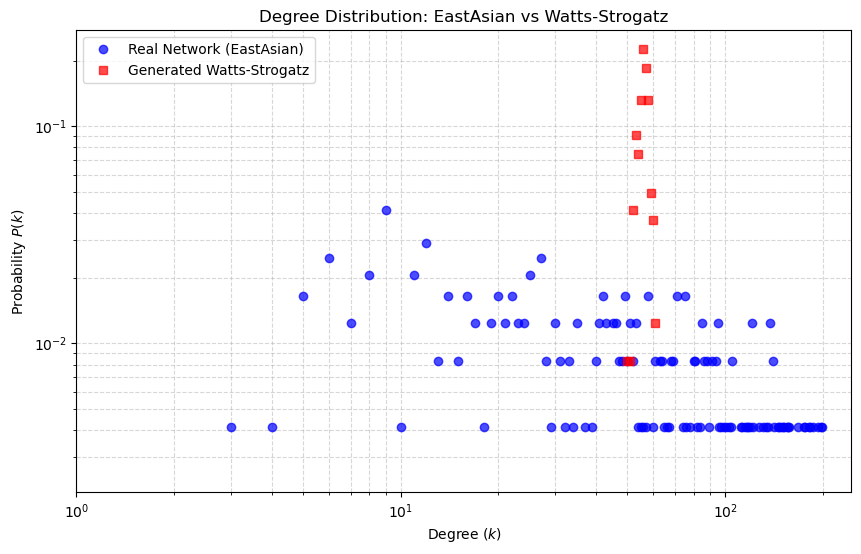

--- Comparación Watts-Strogatz: SouthAsian ---
Nodos (N): 205
Parámetro calculado (K): 52 | Probabilidad reconexión (p): 0.1
Enlaces (E): Real = 5328 | Watts-Strogatz = 5330
Grado Promedio (<k>): Real = 51.980 | Watts-Strogatz = 52.000
Densidad (ρ): Real = 0.25481 | Watts-Strogatz = 0.25490
--------------------------------------------------



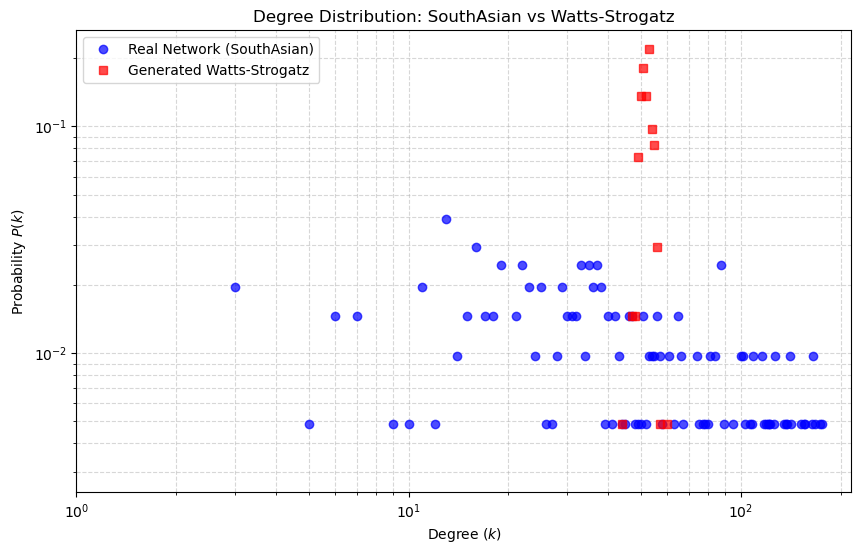

In [84]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def comparacion_watts_strogatz(G, p_rewiring, nombre_red):
    N = G.number_of_nodes()
    E = G.number_of_edges()
    
    k_avg_real = (2 * E) / N
    densidad_real = nx.density(G)
    
    k_ws = int(round(k_avg_real))
    
    G_ws = nx.watts_strogatz_graph(n=N, k=k_ws, p=p_rewiring)
    
    E_ws = G_ws.number_of_edges()
    k_avg_ws = (2 * E_ws) / N
    densidad_ws = nx.density(G_ws)
    
    print(f"--- Comparación Watts-Strogatz: {nombre_red} ---")
    print(f"Nodos (N): {N}")
    print(f"Parámetro calculado (K): {k_ws} | Probabilidad reconexión (p): {p_rewiring}")
    print(f"Enlaces (E): Real = {E} | Watts-Strogatz = {E_ws}")
    print(f"Grado Promedio (<k>): Real = {k_avg_real:.3f} | Watts-Strogatz = {k_avg_ws:.3f}")
    print(f"Densidad (\u03c1): Real = {densidad_real:.5f} | Watts-Strogatz = {densidad_ws:.5f}")
    print("-" * 50 + "\n")
    
    return G_ws, k_ws

def plot_degree_distribution_ws(G, G_ws, network_name, name):
    degrees_real = [d for n, d in G.degree()]
    degrees_ws = [d for n, d in G_ws.degree()]
    
    k_real, counts_real = np.unique(degrees_real, return_counts=True)
    pk_real = counts_real / sum(counts_real)
    
    k_ws, counts_ws = np.unique(degrees_ws, return_counts=True)
    pk_ws = counts_ws / sum(counts_ws)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(k_real, pk_real, 'bo', label=f'Real Network ({network_name})', alpha=0.7)
    plt.plot(k_ws, pk_ws, 'rs', label='Generated Watts-Strogatz', alpha=0.7)
    
    plt.title(f'Degree Distribution: {network_name} vs Watts-Strogatz')
    plt.xlabel('Degree ($k$)')
    plt.ylabel('Probability $P(k)$')
    
    plt.xscale('log')
    plt.yscale('log')
    
    plt.xlim(left=1)
    plt.ylim(bottom=min(min(pk_real), min(pk_ws)) / 2)
    
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.savefig(name)
    plt.show()

p_ws = 0.1

ws_east, k_east = comparacion_watts_strogatz(g_e, p_ws, "EastAsian")
plot_degree_distribution_ws(g_e, ws_east, "EastAsian", "Comparacion East WS")

ws_south, k_south = comparacion_watts_strogatz(g_s, p_ws, "SouthAsian")
plot_degree_distribution_ws(g_s, ws_south, "SouthAsian", "Comparacion South WS")